In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [3]:
df_1=pd.read_csv('data1.csv')    # Biometric datasets
df_2=pd.read_csv('data2.csv')
df_3=pd.read_csv('data3.csv')
df_4=pd.read_csv('data4.csv')


In [4]:
len(df_1)+len(df_2)+len(df_3)+len(df_4)      #Total rows in datasets

1861108

In [5]:

final_df =pd.concat([df_1,df_2,df_3,df_4],ignore_index=True)         #Merged final dataset 

In [6]:
len(final_df)

1861108

In [7]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   date          object
 1   state         object
 2   district      object
 3   pincode       int64 
 4   bio_age_5_17  int64 
 5   bio_age_17_   int64 
dtypes: int64(3), object(3)
memory usage: 85.2+ MB


In [8]:
final_df.isna().mean().sort_values(ascending=False)

date            0.0
state           0.0
district        0.0
pincode         0.0
bio_age_5_17    0.0
bio_age_17_     0.0
dtype: float64

In [9]:
final_df['date']=pd.to_datetime(final_df['date'],format='mixed',dayfirst=True,errors='coerce')  #Converting date from string to date-time format

In [10]:
final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   state         object        
 2   district      object        
 3   pincode       int64         
 4   bio_age_5_17  int64         
 5   bio_age_17_   int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 85.2+ MB


In [11]:
final_df['pincode']=final_df['pincode'].astype(str)   #Converting pincode to string

In [12]:
final_df['pincode'].unique()

array(['123029', '852121', '185101', ..., '795121', '814115', '805236'],
      shape=(19707,), dtype=object)

In [13]:
final_df.shape

(1861108, 6)

In [14]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   state         object        
 2   district      object        
 3   pincode       object        
 4   bio_age_5_17  int64         
 5   bio_age_17_   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 85.2+ MB


In [15]:
final_df.groupby('pincode')[['district','state']].nunique().sort_values(by='district',ascending=True).head(10) #Grouping the states&districts to their unique pincodes

,district,state
pincode,,
530012,1,1
507001,1,2
507003,1,2
743405,1,1
743395,1,1
743391,1,1
507119,1,2
743389,1,1
743385,1,1


In [16]:
final_df.shape

(1861108, 6)

In [17]:
import re
def clean_dist_state(name):

    if pd.isna(name):
        return ''

    name = str(name).lower()                      # Making it lowercase
    name = re.sub(r'[\*\(\)\.\-]', '', name)     # removing special characters *, (), ., -
    name = name.replace('\xa0', ' ').strip()     # removing non-breaking spaces & extra spaces
    name = re.sub(r'\s+', ' ', name)             # collapse multiple spaces
    return name


final_df['district']=final_df['district'].apply(clean_dist_state)
final_df['state']=final_df['state'].apply(clean_dist_state)

In [18]:
final_df.shape

(1861108, 6)

In [19]:
sorted(final_df['district'].unique())  #Displaying all the unique names of districts

['?',
 'adilabad',
 'agar malwa',
 'agra',
 'ahilyanagar',
 'ahmadabad',
 'ahmadnagar',
 'ahmed nagar',
 'ahmedabad',
 'aizawl',
 'ajmer',
 'akhera',
 'akola',
 'alappuzha',
 'aligarh',
 'alipurduar',
 'alirajpur',
 'allahabad',
 'alluri sitharama raju',
 'almora',
 'alwar',
 'ambala',
 'ambedkar nagar',
 'amethi',
 'amravati',
 'amreli',
 'amritsar',
 'amroha',
 'anakapalli',
 'anand',
 'anantapur',
 'ananthapur',
 'ananthapuramu',
 'anantnag',
 'andamans',
 'angul',
 'anjaw',
 'annamayya',
 'anugal',
 'anugul',
 'anuppur',
 'araria',
 'ariyalur',
 'arvalli',
 'arwal',
 'ashok nagar',
 'auraiya',
 'aurangabad',
 'aurangabadbh',
 'ayodhya',
 'azamgarh',
 'badgam',
 'bagalkot',
 'bageshwar',
 'baghpat',
 'bagpat',
 'bahraich',
 'bajali',
 'baksa',
 'balaghat',
 'balangir',
 'baleshwar',
 'baleswar',
 'ballari',
 'ballia',
 'bally jagachha',
 'balod',
 'baloda bazar',
 'balotra',
 'balrampur',
 'banas kantha',
 'banaskantha',
 'banda',
 'bandipore',
 'bandipur',
 'bangalore',
 'bangalore

In [20]:
final_df['district'] = final_df['district'].str.replace(r'[^a-z\s]', '', regex=True)   


In [21]:

sorted(final_df['district'].unique())


['',
 'adilabad',
 'agar malwa',
 'agra',
 'ahilyanagar',
 'ahmadabad',
 'ahmadnagar',
 'ahmed nagar',
 'ahmedabad',
 'aizawl',
 'ajmer',
 'akhera',
 'akola',
 'alappuzha',
 'aligarh',
 'alipurduar',
 'alirajpur',
 'allahabad',
 'alluri sitharama raju',
 'almora',
 'alwar',
 'ambala',
 'ambedkar nagar',
 'amethi',
 'amravati',
 'amreli',
 'amritsar',
 'amroha',
 'anakapalli',
 'anand',
 'anantapur',
 'ananthapur',
 'ananthapuramu',
 'anantnag',
 'andamans',
 'angul',
 'anjaw',
 'annamayya',
 'anugal',
 'anugul',
 'anuppur',
 'araria',
 'ariyalur',
 'arvalli',
 'arwal',
 'ashok nagar',
 'auraiya',
 'aurangabad',
 'aurangabadbh',
 'ayodhya',
 'azamgarh',
 'badgam',
 'bagalkot',
 'bageshwar',
 'baghpat',
 'bagpat',
 'bahraich',
 'bajali',
 'baksa',
 'balaghat',
 'balangir',
 'baleshwar',
 'baleswar',
 'ballari',
 'ballia',
 'bally jagachha',
 'balod',
 'baloda bazar',
 'balotra',
 'balrampur',
 'banas kantha',
 'banaskantha',
 'banda',
 'bandipore',
 'bandipur',
 'bangalore',
 'bangalore 

In [22]:
final_df['district'].value_counts().head(30)


district
pune                  11586
thrissur              11165
east godavari         10647
north  parganas       10595
barddhaman            10545
warangal               9976
palakkad               9605
karimnagar             9514
hyderabad              9422
ernakulam              9113
medak                  9020
tirunelveli            9003
thiruvananthapuram     8913
bengaluru              8671
west godavari          8625
nalgonda               8461
vellore                8335
krishna                8309
guntur                 8208
bangalore              8132
kollam                 7997
khammam                7810
kottayam               7806
coimbatore             7768
malappuram             7727
thanjavur              7694
prakasam               7638
mumbai                 7603
alappuzha              7549
belgaum                7524
Name: count, dtype: int64

In [23]:
sorted(final_df['district'].unique())

['',
 'adilabad',
 'agar malwa',
 'agra',
 'ahilyanagar',
 'ahmadabad',
 'ahmadnagar',
 'ahmed nagar',
 'ahmedabad',
 'aizawl',
 'ajmer',
 'akhera',
 'akola',
 'alappuzha',
 'aligarh',
 'alipurduar',
 'alirajpur',
 'allahabad',
 'alluri sitharama raju',
 'almora',
 'alwar',
 'ambala',
 'ambedkar nagar',
 'amethi',
 'amravati',
 'amreli',
 'amritsar',
 'amroha',
 'anakapalli',
 'anand',
 'anantapur',
 'ananthapur',
 'ananthapuramu',
 'anantnag',
 'andamans',
 'angul',
 'anjaw',
 'annamayya',
 'anugal',
 'anugul',
 'anuppur',
 'araria',
 'ariyalur',
 'arvalli',
 'arwal',
 'ashok nagar',
 'auraiya',
 'aurangabad',
 'aurangabadbh',
 'ayodhya',
 'azamgarh',
 'badgam',
 'bagalkot',
 'bageshwar',
 'baghpat',
 'bagpat',
 'bahraich',
 'bajali',
 'baksa',
 'balaghat',
 'balangir',
 'baleshwar',
 'baleswar',
 'ballari',
 'ballia',
 'bally jagachha',
 'balod',
 'baloda bazar',
 'balotra',
 'balrampur',
 'banas kantha',
 'banaskantha',
 'banda',
 'bandipore',
 'bandipur',
 'bangalore',
 'bangalore 

In [24]:
district_alias_map = {

    # Updating Renamed districts
    'aurangabad': 'chhatrapati sambhajinagar',
    'chatrapati sambhaji nagar': 'chhatrapati sambhajinagar',
    'osmanabad': 'dharashiv',


    'bangalore': 'bengaluru',
    'mysore': 'mysuru',


    'ahmadabad': 'ahmedabad',
    'ahmed nagar': 'ahmadnagar',

    
    'hooghly': 'hugli',
    'hooghiy': 'hugli',

 
    'barddhaman': 'bardhaman',
    'burdwan': 'bardhaman',

   
    'east midnapur': 'east midnapore',
    'west midnapore': 'west medinipur',

   
    'darjiling': 'darjeeling',

   
    'belgaum': 'belagavi',

   
    'bellary': 'ballari',

    
    'bijapurkar': 'bijapur',

    
    'kanniyakumari': 'kanyakumari',

   
    'kasargod': 'kasaragod',

 
    'rangareddi': 'rangareddy',
    'kv rangareddy': 'rangareddy',
    'kvrangareddy': 'rangareddy',

    
    'janjgirchampa': 'janjgir champa',

   
    'medchalmalkajgiri': 'medchal malkajgiri',

    
    'gaurelapendramarwahi': 'gaurela pendra marwahi',

    
    'lahul  spiti': 'lahaul and spiti',
    'lahul and spiti': 'lahaul and spiti',

   
    'north  parganas': 'north twenty four parganas',
    'south  parganas': 'south twenty four parganas',
    'south  pargana': 'south twenty four parganas',

  
    'rae bareli': 'raebareli',

    
    'n t r': 'ntr',
    'y s r': 'ysr',

  
    'dadra  nagar haveli': 'dadra and nagar haveli',

   
    'mumbai sub urban': 'mumbai suburban',

   
    'sundergarh': 'sundargarh'
}

final_df['district'] = final_df['district'].replace(district_alias_map)


In [25]:
final_df.shape

(1861108, 6)

In [26]:
print("Unique districts after mapping:", final_df['district'].nunique())
final_df['district'].value_counts().head(20)


Unique districts after mapping: 892


district
bengaluru                     16803
belagavi                      14424
bardhaman                     14038
north twenty four parganas    13429
rangareddy                    12209
pune                          11586
thrissur                      11165
east godavari                 10647
warangal                       9976
palakkad                       9605
karimnagar                     9514
hyderabad                      9422
south twenty four parganas     9349
ernakulam                      9113
medak                          9020
tirunelveli                    9003
kanyakumari                    8916
thiruvananthapuram             8913
ahmadnagar                     8910
mysuru                         8779
Name: count, dtype: int64

In [29]:
final_df.shape

(1861108, 6)

In [30]:
final_df['district'].replace('', pd.NA, inplace=True)  #Removing empty space


C:\Users\nikhi\AppData\Local\Temp\ipykernel_24304\3794126188.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['district'].replace('', pd.NA, inplace=True)  #Removing empty space


In [31]:
final_df = final_df.dropna(subset=['district'])


In [32]:
final_df.shape

(1859633, 6)

In [33]:
#Correcting the spellings of districts
district_fix_map = {
    'anugal':'angul',
    'anugul':'angul',
    'baghpat':'bagpat',
    'bara banki':'barabanki',
    'chamrajanagar':'chamarajanagar',
    'chamrajnagar':'chamarajanagar',
    'davangere':'davanagere',
    'dohad':'dahod',
    'gondiya':'gondia',
    'hawrah':'howrah',
    'haora':'howrah',
    'hazaribag':'hazaribagh',
    'jangoan':'jangaon',
    'kancheepuram':'kanchipuram',
    'karim nagar':'karimnagar',
    'khorda':'khordha',
    'koderma':'kodarma',
    'mammit':'mamit',
    'mahabub nagar':'mahabubnagar',
    'maldah':'malda',
    'monghyr':'munger',
    'palamau':'palamu',
    'purnia':'purnea',
    'puruliya':'purulia',
    'samstipur':'samastipur',
    'sheikpura':'sheikhpura',
    'shimoga':'shivamogga',
    'surendra nagar':'surendranagar',
    'tumkur':'tumakuru',
    'tuticorin':'thoothukkudi',
    'yamunanagar':'yamuna nagar'
}

final_df['district'] = final_df['district'].replace(district_fix_map)


In [34]:
invalid = ['east','west','north','south','north east']    
final_df = final_df[~final_df['district'].isin(invalid)]


In [35]:
final_df.shape

(1859633, 6)

In [36]:
official_rename_map = {
    'allahabad': 'prayagraj',
    'faizabad': 'ayodhya',
    'ahmadnagar': 'ahilyanagar',
    'aurangabadbh': 'chhatrapati sambhajinagar',
    'osmanabad': 'dharashiv',
    'hoshiangabad': 'narmadapuram',
    'bid': 'beed'
}

final_df['district'] = final_df['district'].replace(official_rename_map)


In [37]:
# Ensuring old names are gone
set(official_rename_map.keys()) & set(final_df['district'].unique())


set()

In [38]:
sorted(final_df['district'].unique())

['adilabad',
 'agar malwa',
 'agra',
 'ahilyanagar',
 'ahmedabad',
 'aizawl',
 'ajmer',
 'akhera',
 'akola',
 'alappuzha',
 'aligarh',
 'alipurduar',
 'alirajpur',
 'alluri sitharama raju',
 'almora',
 'alwar',
 'ambala',
 'ambedkar nagar',
 'amethi',
 'amravati',
 'amreli',
 'amritsar',
 'amroha',
 'anakapalli',
 'anand',
 'anantapur',
 'ananthapur',
 'ananthapuramu',
 'anantnag',
 'andamans',
 'angul',
 'anjaw',
 'annamayya',
 'anuppur',
 'araria',
 'ariyalur',
 'arvalli',
 'arwal',
 'ashok nagar',
 'auraiya',
 'ayodhya',
 'azamgarh',
 'badgam',
 'bagalkot',
 'bageshwar',
 'bagpat',
 'bahraich',
 'bajali',
 'baksa',
 'balaghat',
 'balangir',
 'baleshwar',
 'baleswar',
 'ballari',
 'ballia',
 'bally jagachha',
 'balod',
 'baloda bazar',
 'balotra',
 'balrampur',
 'banas kantha',
 'banaskantha',
 'banda',
 'bandipore',
 'bandipur',
 'bangalore rural',
 'banka',
 'bankura',
 'banswara',
 'bapatla',
 'barabanki',
 'baramula',
 'baran',
 'bardez',
 'bardhaman',
 'bareilly',
 'bargarh',
 '

In [39]:
final_df.shape

(1859633, 6)

In [40]:
category3_fix = {
    'hoshangabad': 'narmadapuram',
    'mahbubnagar': 'mahabubnagar',
    'bidar': 'beed',
    'bijapur': 'vijayapura',
    'gulbarga': 'kalaburagi',
    'allahabad': 'prayagraj',
    'faizabad': 'ayodhya'
}

final_df['district'] = final_df['district'].replace(category3_fix)


In [41]:
district_map = {
    "baleswar": "baleshwar",
    "baleshwar": "baleshwar",

    "bulandshahar": "bulandshahr",
    "bulandshahr": "bulandshahr",

    "jhunjhunun": "jhunjhunu",
    "jhunjhunu": "jhunjhunu",

    "jalor": "jalore",
    "jalore": "jalore",

    "panch mahals": "panchmahals",
    "panchmahals": "panchmahals",

    "sabar kantha": "sabarkantha",
    "sabarkantha": "sabarkantha",

    "villupuram": "viluppuram",
    "viluppuram": "viluppuram",

    "sas nagarmohali": "sas nagar mohali",
    "sas nagar mohali": "sas nagar mohali"
}

final_df['district'] = final_df['district'].replace(district_map)

In [42]:
final_df.shape

(1859633, 6)

In [43]:
canonical_map = {
    "ananthapur": "anantapur",
    "ananthapuramu": "anantapur",
    "mahrajganj": "maharajganj",
    "rae bareli": "raebareli",
}
final_df["district"] = final_df["district"].replace(canonical_map)


In [44]:
canonical_map.update({
    "jajapur": "jajpur",
    "koch bihar": "cooch behar",
    "baudh": "boudh",
    "sahebganj": "sahibganj",
    "rajaouri": "rajouri",
    "poonch": "punch",
})
final_df["district"] = final_df["district"].replace(canonical_map)


In [45]:
fix_map = {
    "raigarhmh": "raigarh",
    "tamulpur district": "tamulpur"
}
final_df["district"] = final_df["district"].replace(fix_map)

In [46]:
final_df.shape

(1859633, 6)

In [47]:
alias_map = {
    "haridwar": "haridwar",
    "hardwar": "haridwar",
    "jalor": "jalore",
    "villupuram": "viluppuram",
    "tirupathur": "tirupattur",
    "rajauri": "rajouri",
    "buldana": "buldhana",
    "hugli": "hooghly"
}
final_df["district"] = (
    final_df["district"]
    .str.lower()
    .str.strip()
    .replace(alias_map)
)



In [48]:
final_df.shape        #Count of rows after making changes

(1859633, 6)

In [49]:
manual_fixes = {
    "manendragarhchirmiribharatpur": "manendragarh",
    "mohallamanpurambagarh chowki": "ambagarh chowki"
}

final_df["district"] = final_df["district"].replace(manual_fixes)


In [50]:
sorted(final_df['district'].unique())

['adilabad',
 'agar malwa',
 'agra',
 'ahilyanagar',
 'ahmedabad',
 'aizawl',
 'ajmer',
 'akhera',
 'akola',
 'alappuzha',
 'aligarh',
 'alipurduar',
 'alirajpur',
 'alluri sitharama raju',
 'almora',
 'alwar',
 'ambagarh chowki',
 'ambala',
 'ambedkar nagar',
 'amethi',
 'amravati',
 'amreli',
 'amritsar',
 'amroha',
 'anakapalli',
 'anand',
 'anantapur',
 'anantnag',
 'andamans',
 'angul',
 'anjaw',
 'annamayya',
 'anuppur',
 'araria',
 'ariyalur',
 'arvalli',
 'arwal',
 'ashok nagar',
 'auraiya',
 'ayodhya',
 'azamgarh',
 'badgam',
 'bagalkot',
 'bageshwar',
 'bagpat',
 'bahraich',
 'bajali',
 'baksa',
 'balaghat',
 'balangir',
 'baleshwar',
 'ballari',
 'ballia',
 'bally jagachha',
 'balod',
 'baloda bazar',
 'balotra',
 'balrampur',
 'banas kantha',
 'banaskantha',
 'banda',
 'bandipore',
 'bandipur',
 'bangalore rural',
 'banka',
 'bankura',
 'banswara',
 'bapatla',
 'barabanki',
 'baramula',
 'baran',
 'bardez',
 'bardhaman',
 'bareilly',
 'bargarh',
 'barmer',
 'barnala',
 'bar

In [51]:
alias_map = {
    "banas kantha": "banaskantha",
    "bangalore rural": "bengaluru rural",
    "buldana": "buldhana",
    "hugli": "hooghly",
    "hasan": "hassan",
    "rajauri": "rajouri",
    "haridwar": "haridwar",
    "hardwar": "haridwar",
    "nicobars": "nicobar",
    "tirupathur": "tirupattur",
    "villupuram": "viluppuram"
}

final_df["district"] = final_df["district"].replace(alias_map)


In [52]:
legacy_names = [
    "bardhaman",
    "garhwal",
    "east nimar",
    "west nimar",
    "andamans",
    "leh ladakh"
]

final_df = final_df[~final_df["district"].isin(legacy_names)]


In [53]:
final_df.shape

(1842826, 6)

In [54]:
manual_fixes = {
    "manendragarhchirmiribharatpur": "manendragarh",
    "mohallamanpurambagarh chowki": "ambagarh chowki",
    "mohlamanpurambagarh chouki": "ambagarh chowki",
    "sarangarhbilaigarh": "sarangarh bilaigarh",
    "seraikelakharsawan": "seraikela kharsawan"
}

final_df["district"] = final_df["district"].replace(manual_fixes)


In [55]:
not_districts = [       #Removing names which are not districts according to the current data
    "najafgarh",
    "domjur",
    "south dumdumm",
    "bally jagachha",
    "bangalore south",
    "yanam"
]

final_df = final_df[~final_df["district"].isin(not_districts)]


In [56]:
final_df.shape

(1842634, 6)

In [57]:
final_col = "district"
final_districts = (
    final_df[final_col]
    .value_counts()
    .reset_index()
)

final_districts.columns = ["district", "count"]
final_districts = final_districts.sort_values("district")
final_districts.head(20)


,district,count
51,adilabad,6934
663,agar malwa,482
245,agra,2358
18,ahilyanagar,8926
23,ahmedabad,8730
529,aizawl,1059
128,ajmer,4104
805,akhera,1
242,akola,2380
40,alappuzha,7549


In [58]:
final_df.shape

(1842634, 6)

In [59]:
final_df.shape

(1842634, 6)

In [60]:
state_ut_names = [          #Removing UTs from distict columns
    "chandigarh",
    "dadra and nagar haveli",
    "puducherry"
]

final_df= final_df[~final_df["district"].str.lower().isin(state_ut_names)]


In [61]:
print("Final unique districts:", final_df.shape[0])


Final unique districts: 1838540


In [62]:
final_df = final_df[                               #Removing unnecessary words
    ~final_df['district'].str.contains(
        r'\b(near|road|colony|cross|dist\s*:)\b',
        case=False,
        na=False
    )
]

final_df = final_df[~final_df['district'].str.isnumeric()]

C:\Users\nikhi\AppData\Local\Temp\ipykernel_24304\2794279795.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~final_df['district'].str.contains(


In [63]:
final_df.shape

(1838540, 6)

In [64]:
final_df['state'].value_counts().sort_index()      #Checking the list of states

state
andaman & nicobar islands                      192
andaman and nicobar islands                   1298
andhra pradesh                              172065
arunachal pradesh                             4244
assam                                        47643
bihar                                        83398
chandigarh                                      18
chhatisgarh                                      5
chhattisgarh                                 31992
dadra and nagar haveli and daman and diu        95
daman & diu                                    264
daman and diu                                  412
delhi                                         8929
goa                                           5428
gujarat                                      89531
haryana                                      26429
himachal pradesh                             30385
jammu & kashmir                                360
jammu and kashmir                            19589
jharkhand                

In [65]:
#Correcting the list of states and renaming same states carefully 

state_alias_map = {
    "andaman nicobar islands": "andaman and nicobar islands",
    "andaman nicobar island": "andaman and nicobar islands",

    "jammu kashmir": "jammu and kashmir",

    "orissa": "odisha",

    "tamilnadu": "tamil nadu",

    "uttaranchal": "uttarakhand",

    "west bangal": "west bengal",
    "westbengal": "west bengal",

    "pondicherry": "puducherry",

    "daman diu": "dadra and nagar haveli and daman and diu",
    "daman and diu": "dadra and nagar haveli and daman and diu"
}

final_df["state"] = final_df["state"].replace(state_alias_map)


In [66]:
final_df["state"] = final_df["state"].replace({
    "chhatisgarh": "chhattisgarh"
})


In [67]:
official_states = {                    #Checking invalid states
    "andaman and nicobar islands",
    "andhra pradesh",
    "arunachal pradesh",
    "assam",
    "bihar",
    "chandigarh",
    "chhattisgarh",
    "delhi",
    "goa",
    "gujarat",
    "haryana",
    "himachal pradesh",
    "jammu and kashmir",
    "jharkhand",
    "karnataka",
    "kerala",
    "ladakh",
    "lakshadweep",
    "madhya pradesh",
    "maharashtra",
    "manipur",
    "meghalaya",
    "mizoram",
    "nagaland",
    "odisha",
    "puducherry",
    "punjab",
    "rajasthan",
    "sikkim",
    "tamil nadu",
    "telangana",
    "tripura",
    "uttar pradesh",
    "uttarakhand",
    "west bengal",
    "dadra and nagar haveli and daman and diu"
}

invalid_states = set(final_df["state"]) - official_states
print("Invalid states:", invalid_states)


Invalid states: {'andaman & nicobar islands', 'jammu & kashmir', 'daman & diu'}


In [68]:
alias_map = {
    "andaman & nicobar islands": "andaman and nicobar islands",

    "jammu & kashmir": "jammu and kashmir",

    "daman & diu": "dadra and nagar haveli and daman and diu"
}

final_df["state"] = final_df["state"].replace(alias_map)


In [69]:
official_states = {
    "andaman and nicobar islands",
    "andhra pradesh",
    "arunachal pradesh",
    "assam",
    "bihar",
    "chandigarh",
    "chhattisgarh",
    "delhi",
    "goa",
    "gujarat",
    "haryana",
    "himachal pradesh",
    "jammu and kashmir",
    "jharkhand",
    "karnataka",
    "kerala",
    "ladakh",
    "lakshadweep",
    "madhya pradesh",
    "maharashtra",
    "manipur",
    "meghalaya",
    "mizoram",
    "nagaland",
    "odisha",
    "puducherry",
    "punjab",
    "rajasthan",
    "sikkim",
    "tamil nadu",
    "telangana",
    "tripura",
    "uttar pradesh",
    "uttarakhand",
    "west bengal",
    "dadra and nagar haveli and daman and diu"
}

invalid_states = set(final_df["state"]) - official_states
print("Invalid states:", invalid_states)


Invalid states: set()


In [70]:
value = final_df['state'].value_counts().sort_index()
print(value)
print(len(value))

state
andaman and nicobar islands                   1490
andhra pradesh                              172065
arunachal pradesh                             4244
assam                                        47643
bihar                                        83398
chandigarh                                      18
chhattisgarh                                 31997
dadra and nagar haveli and daman and diu       771
delhi                                         8929
goa                                           5428
gujarat                                      89531
haryana                                      26429
himachal pradesh                             30385
jammu and kashmir                            19949
jharkhand                                    36625
karnataka                                   141227
kerala                                       98511
ladakh                                         733
lakshadweep                                    550
madhya pradesh           

In [71]:
#Removing duplicate rows

before = len(final_df)

final_df = final_df.drop_duplicates()

after = len(final_df)

print(f"Removed {before - after} duplicate rows")

Removed 97969 duplicate rows


In [72]:
final_df.shape

(1740571, 6)

In [73]:
sort_cols = ["date", "state", "district"]     #Sorting the dataset 
df_sorted = final_df.sort_values(
    by=sort_cols,
    ascending=[True, True, True]
)


In [74]:
df_sorted = df_sorted.reset_index(drop=True)


In [75]:
df_sorted.head(10)


,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,2025-03-01,andaman and nicobar islands,nicobar,744301,101,48
1,2025-03-01,andaman and nicobar islands,nicobar,744302,15,12
2,2025-03-01,andaman and nicobar islands,nicobar,744303,46,27
3,2025-03-01,andaman and nicobar islands,nicobar,744304,16,14
4,2025-03-01,andaman and nicobar islands,north and middle andaman,744202,167,131
5,2025-03-01,andaman and nicobar islands,north and middle andaman,744201,41,40
6,2025-03-01,andaman and nicobar islands,north and middle andaman,744205,122,69
7,2025-03-01,andaman and nicobar islands,north and middle andaman,744210,17,17
8,2025-03-01,andaman and nicobar islands,north and middle andaman,744209,20,14
9,2025-03-01,andaman and nicobar islands,north and middle andaman,744204,103,76


In [76]:
df_sorted.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1740571 entries, 0 to 1740570
Data columns (total 6 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   state         object        
 2   district      object        
 3   pincode       object        
 4   bio_age_5_17  int64         
 5   bio_age_17_   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 79.7+ MB


In [77]:
df_sorted[['bio_age_5_17', 'bio_age_17_']].describe()


,bio_age_5_17,bio_age_17_
count,1.740571e+06,1.740571e+06
mean,1.911874e+01,1.984536e+01
std,8.613296e+01,9.051908e+01
min,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.000000e+00
50%,4.000000e+00,4.000000e+00
75%,1.100000e+01,1.100000e+01
max,8.002000e+03,7.625000e+03


<Axes: title={'center': 'Daily Biometric Activity'}, xlabel='date'>

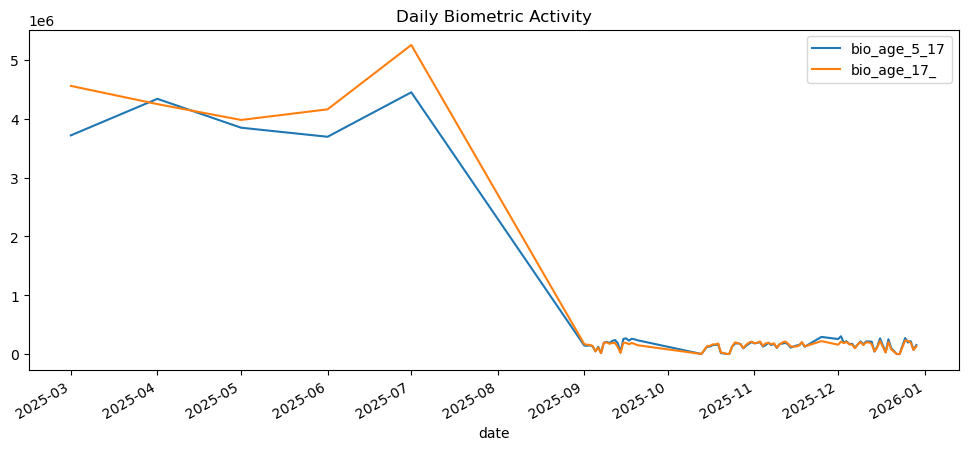

In [78]:
daily = df_sorted.groupby('date')[['bio_age_5_17', 'bio_age_17_']].sum()

daily.plot(figsize=(12,5), title="Daily Biometric Activity")



In [79]:
state_summary = df_sorted.groupby('state')[['bio_age_5_17', 'bio_age_17_']].sum().sort_values(by='bio_age_17_', ascending=False)

state_summary.head(10)


,bio_age_5_17,bio_age_17_
state,,
maharashtra,3437075,5583527
uttar pradesh,6076411,3290641
madhya pradesh,3135955,2634544
bihar,2160544,2618419
tamil nadu,2153064,2418644
rajasthan,2032782,1895206
chhattisgarh,839394,1719709
gujarat,1437928,1709917
andhra pradesh,2180906,1428135


In [80]:
newdf = df_sorted.copy()
newdf.head(20)

,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,2025-03-01,andaman and nicobar islands,nicobar,744301,101,48
1,2025-03-01,andaman and nicobar islands,nicobar,744302,15,12
2,2025-03-01,andaman and nicobar islands,nicobar,744303,46,27
3,2025-03-01,andaman and nicobar islands,nicobar,744304,16,14
4,2025-03-01,andaman and nicobar islands,north and middle andaman,744202,167,131
5,2025-03-01,andaman and nicobar islands,north and middle andaman,744201,41,40
6,2025-03-01,andaman and nicobar islands,north and middle andaman,744205,122,69
7,2025-03-01,andaman and nicobar islands,north and middle andaman,744210,17,17
8,2025-03-01,andaman and nicobar islands,north and middle andaman,744209,20,14
9,2025-03-01,andaman and nicobar islands,north and middle andaman,744204,103,76


In [81]:
import pandas as pd
import matplotlib.pyplot as plt

newdf['total_bio'] = newdf['bio_age_5_17'] + newdf['bio_age_17_']




In [82]:
newdf['year_month'] = newdf['date'].dt.to_period('M')


In [83]:
monthly_trend = (
    newdf
    .groupby('year_month')['total_bio']
    .sum()
    .reset_index()
)


In [84]:
monthly_trend['month_name'] = monthly_trend['year_month'].dt.strftime('%b %Y')


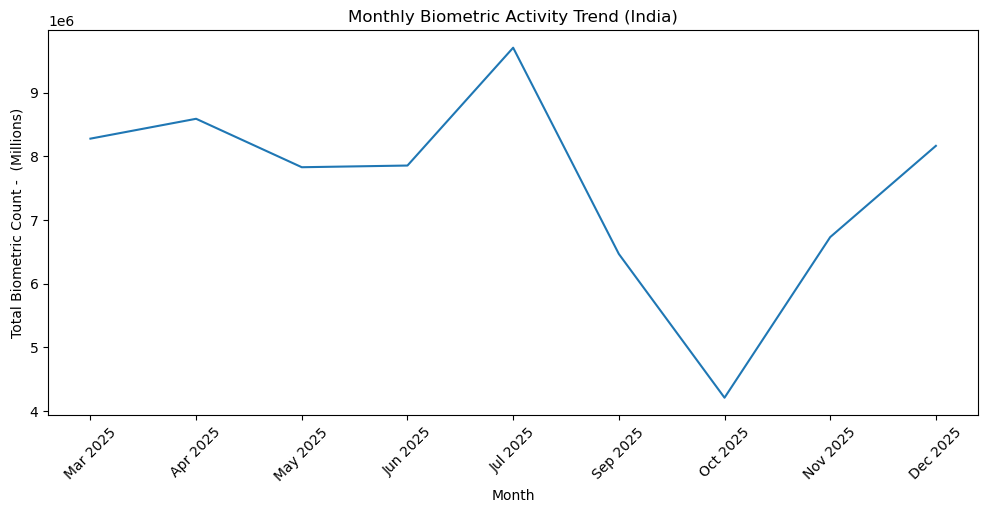

In [85]:
plt.figure(figsize=(12,5))
plt.plot(monthly_trend['month_name'], monthly_trend['total_bio'])
plt.title("Monthly Biometric Activity Trend (India)")
plt.xlabel("Month")
plt.ylabel("Total Biometric Count -  (Millions)")
plt.xticks(rotation=45)
plt.savefig("monthly_biometric_activity.png", dpi=300, bbox_inches="tight")
plt.show()


#Insight A — Mid-year peak (July 2025)
Biometric activity peaks sharply around July
Indicates planned or cyclical mass enrolment/update activity

Insight B — Sharp collapse in Sep–Oct 2025
A sudden ~50% drop from July to October
This is not normal seasonality

Suggests:
Operational disruption
Infrastructure bottleneck
Policy-driven pause
External shock (monsoon, elections, system changes)

Insight C — Strong recovery post-October
Rapid rebound in Nov–Dec
Indicates pent-up demand
Backlog accumulation during low-activity months

**Action **
UIDAI should implement month-ahead biometric demand forecasting using historical enrolment/update data to:

Pre-scale server capacity
Increase operator availability
Allocate mobile enrolment kits proactively


Government Function Impacted:

UIDAI Infrastructure & Technology Division
Aadhaar Enrolment Ecosystem Management

Policy Alignment:
Digital India – Scalable Digital Public Infrastructure
UIDAI’s mandate for high availability & low latency

Expected Impact:

Reduced authentication failures
Faster enrolment & update turnaround
Improved citizen experience during peak months


UIDAI ACTION 2: Early-Warning System for Operational Disruptions
Insight Triggered:

Abrupt drop during Sep–Oct (anomaly, not seasonality)

Action:

Introduce an automated anomaly detection system that flags:

Sudden month-over-month drops at national/state/district level

Persistent under-performance beyond historical norms

This alert should trigger:

Root-cause investigation

Emergency operational interventions

Government Function Impacted:

UIDAI Operations & Monitoring

Regional UIDAI Offices

Enrolment Agency Oversight


Policy Alignment:

Proactive Governance

Real-time Monitoring of Critical Digital Infrastructure

Expected Impact:

Faster response to outages or administrative bottlenecks

Prevention of silent service failures

Increased system resilience

🔹 UIDAI ACTION 3: Backlog-Aware Recovery Planning
Insight Triggered:

Strong rebound after October (pent-up demand)
Action:

After detecting prolonged dips, UIDAI should:

Launch short-term recovery drives

Temporarily increase enrolment/update capacity
Prioritize high-backlog regions

Government Function Impacted:
Enrolment & Update Program Management
State UIDAI Coordination Units

Policy Alignment:
Inclusive Governance
Last-mile Aadhaar Coverage

Expected Impact:
Faster clearance of pending Aadhaar updates
Reduced citizen wait times
Improved trust in Aadhaar services

In [86]:
monthly_state = (
    newdf.groupby(['year_month', 'state'])['total_bio']
    .sum()
    .reset_index()
)


In [87]:
spike_month = '2025-07'
spike_data = monthly_state[monthly_state['year_month'] == spike_month]


In [88]:
spike_ranked = spike_data.sort_values(
    by='total_bio',
    ascending=False
)


In [ ]:
import matplotlib.pyplot as plt

top_states = spike_ranked.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_states['state'], top_states['total_bio'])
plt.xticks(rotation=45)
plt.title('Top 10 State Contributions – July 2025')
plt.xlabel('State')
plt.ylabel('Total Biometric Activity')
plt.tight_layout()
plt.savefig("top 10 states.png", dpi=300, bbox_inches="tight")
plt.show()


“The July biometric spike is operationally concentrated and disproportionately driven by a small group of high-volume states rather than a uniform nationwide increase.”

This suggests targeted operational triggers or capacity-driven enrolment dynamics in high-volume states

Biometric activity surges are not evenly distributed across states; instead, a small set of high-population states consistently dominate peak-month workloads.


What UIDAI should do:
Shift from uniform monthly capacity planning to state-weighted planning
What UIDAI should implement:Pre-allocate:
Biometric kits
Operators
Network bandwidth
to high-impact states before known peak months

A simple early-warning system:
If top 5 states exceed historical baseline → trigger pre-emptive scaling

What UIDAI should change:
Monthly dashboards should flag high-contribution states separately

Introduce:
“Spike Sensitivity Index” per state

Policy / Governance Impact
Impact:
Reduced system strain, improved service delivery, and proactive governance.

In [90]:
monthly_age = (
    newdf.groupby('year_month')[['bio_age_5_17', 'bio_age_17_']]
    .sum()
    .reset_index()
)


In [91]:
monthly_age['total'] = (
    monthly_age['bio_age_5_17'] +
    monthly_age['bio_age_17_']
)

monthly_age['pct_5_17'] = (
    monthly_age['bio_age_5_17'] / monthly_age['total']
) * 100

monthly_age['pct_17_plus'] = (
    monthly_age['bio_age_17_'] / monthly_age['total']
) * 100


In [92]:
monthly_age[monthly_age['year_month'] == pd.Period('2025-07', freq='M')]


,year_month,bio_age_5_17,bio_age_17_,total,pct_5_17,pct_17_plus
4,2025-07,4449628,5253931,9703559,45.855629,54.144371


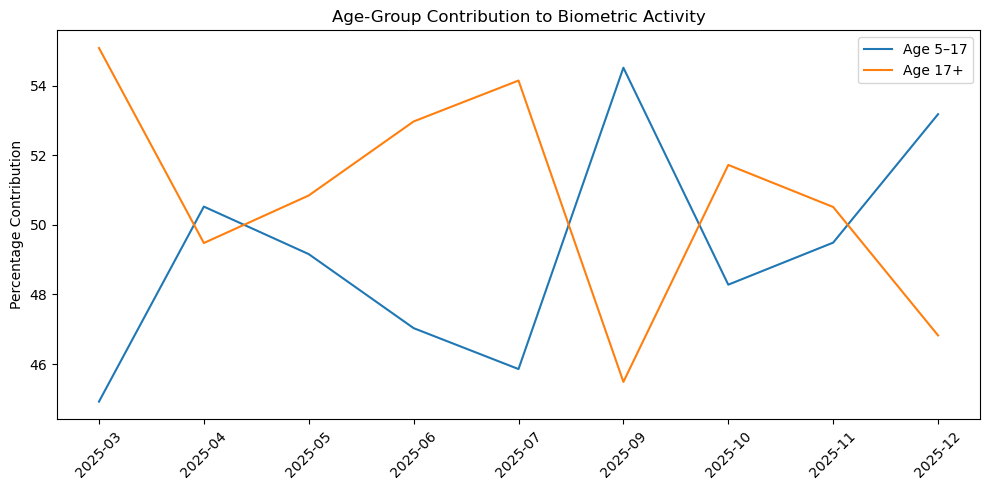

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_age['year_month'].astype(str),
         monthly_age['pct_5_17'],
         label='Age 5–17')

plt.plot(monthly_age['year_month'].astype(str),
         monthly_age['pct_17_plus'],
         label='Age 17+')

plt.xticks(rotation=45)
plt.ylabel('Percentage Contribution')
plt.title('Age-Group Contribution to Biometric Activity')
plt.legend()
plt.tight_layout()
plt.savefig("Age contribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [94]:
print(monthly_age.dtypes)


year_month      period[M]
bio_age_5_17        int64
bio_age_17_         int64
total               int64
pct_5_17          float64
pct_17_plus       float64
dtype: object


The July spike aligns with adult-dominant biometric activity, suggesting demand-side triggers such as welfare authentication, employment-linked verification, or Aadhaar update compliance drives

UIDAI Action Framework from EDA-3

Action 1: Predictive Capacity Planning
Use age-mix trends to pre-allocate biometric kits
Especially before historically adult-heavy months

Action 2: Policy Coordination Signal
Share anonymised spike indicators with ministries
Detect when Aadhaar load correlates with benefit rollouts

Action 3: Load Balancing
Route adult update traffic to off-peak centers
Reduce congestion during demand surges

In [109]:
district_monthly = (
    newdf.groupby(['year_month', 'state', 'district'])[
        ['bio_age_5_17', 'bio_age_17_']
    ]
    .sum()
    .reset_index()
)

district_monthly['total_bio'] = (
    district_monthly['bio_age_5_17'] +
    district_monthly['bio_age_17_']
)


In [110]:
july_data = district_monthly[
    district_monthly['year_month'] == pd.Period('2025-07', freq='M')
]


In [111]:
top_districts_july = (
    july_data
    .sort_values(by='total_bio', ascending=False)
    .head(15)
)

top_districts_july[['state', 'district', 'total_bio']]



,state,district,total_bio
3550,maharashtra,nashik,83938
3553,maharashtra,pune,83000
3426,karnataka,bengaluru,76283
3561,maharashtra,thane,74661
3305,gujarat,ahmedabad,66780
3540,maharashtra,jalgaon,62477
3544,maharashtra,mumbai,52979
3687,rajasthan,jaipur,52457
3534,maharashtra,chhatrapati sambhajinagar,49607
3548,maharashtra,nanded,46666


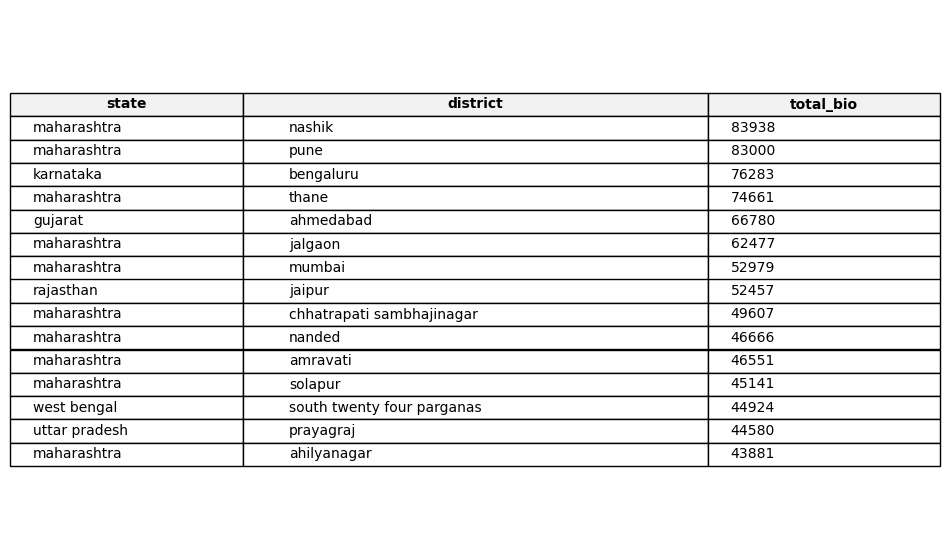

In [112]:
import matplotlib.pyplot as plt


table_df = top_districts_july[['state', 'district', 'total_bio']].copy()


fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')


table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc='left',
    loc='center',
    colWidths=[0.25, 0.50, 0.25]
)


table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)


for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#F2F2F2')


for (row, col), cell in table.get_celld().items():
    if col == 2 and row != 0:
        cell._loc = 'right'


plt.savefig(
    "top_15_districts_july.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [116]:
june_data = district_monthly[
    district_monthly['year_month'] == pd.Period('2025-06', freq='M')
]

district_comparison = july_data.merge(
    june_data,
    on=['state', 'district'],
    suffixes=('_july', '_june')
)

district_comparison['growth_pct'] = (
    (district_comparison['total_bio_july'] -
     district_comparison['total_bio_june'])
    / district_comparison['total_bio_june']
) * 100


In [117]:
district_anomalies = (
    district_comparison
    .sort_values(by='growth_pct', ascending=False)
    .head(10)
)

district_anomalies[['state', 'district', 'growth_pct']]


,state,district,growth_pct
447,manipur,imphal east,1303.415560
453,manipur,thoubal,951.781857
444,manipur,bishnupur,903.983657
450,manipur,kakching,773.333333
448,manipur,imphal west,757.594937
451,manipur,senapati,330.225080
377,madhya pradesh,maihar,302.597403
454,manipur,ukhrul,302.295918
449,manipur,jiribam,253.956835
699,uttar pradesh,hamirpur,219.136582


Insight 1 (From Image 1 – High Volume)
Problem: Urban districts always dominate load
Action: Permanent infrastructure strengthening

Insight 2 (From Image 2 – High Growth)
Problem: Sudden, unpredictable local surges
Action: Early-warning & rapid response system


roposed UIDAI System

“District-Level Biometric Surge Monitor”
Monthly anomaly detection using MoM growth
Auto-flag districts crossing threshold (e.g., >200%)

Trigger:
Mobile enrolment kits
Temporary staffing
State coordination alerts

Policy & Governance Impact
Area	Impact
UIDAI Ops	Prevent service collapse
NE States	Targeted capacity support
Cost	Lower emergency deployment
Big districts explain load. Small districts explain spikes.

In [118]:
state_monthly = (
    newdf.groupby(['year_month', 'state'])[
        ['bio_age_5_17', 'bio_age_17_']
    ]
    .sum()
    .reset_index()
)

state_monthly['total_bio'] = (
    state_monthly['bio_age_5_17'] +
    state_monthly['bio_age_17_']
)


In [119]:
state_july = state_monthly[state_monthly['year_month'] == pd.Period('2025-07', freq='M')]
state_june = state_monthly[state_monthly['year_month'] == pd.Period('2025-06', freq='M')]

state_growth = state_july.merge(
    state_june,
    on='state',
    suffixes=('_july', '_june')
)

state_growth['growth_pct'] = (
    (state_growth['total_bio_july'] -
     state_growth['total_bio_june'])
    / state_growth['total_bio_june']
) * 100


In [120]:
state_growth_sorted = state_growth.sort_values(
    by='growth_pct',
    ascending=False
)

state_growth_sorted[['state', 'growth_pct']].head(10)


,state,growth_pct
20,manipur,667.734513
16,ladakh,92.330383
32,uttar pradesh,66.500400
10,haryana,61.748512
6,dadra and nagar haveli and daman and diu,61.040609
27,rajasthan,56.017231
34,west bengal,44.690188
0,andaman and nicobar islands,42.405765
33,uttarakhand,38.861100
3,assam,32.966357


In [121]:
district_share = july_data.copy()

district_share['state_total'] = district_share.groupby('state')['total_bio'].transform('sum')

district_share['district_share_pct'] = (
    district_share['total_bio'] / district_share['state_total']
) * 100


In [122]:
top_concentration = (
    district_share
    .sort_values(by='district_share_pct', ascending=False)
    .groupby('state')
    .head(1)
    .sort_values(by='district_share_pct', ascending=False)
)

top_concentration[['state', 'district', 'district_share_pct']].head(15)


,state,district,district_share_pct
3471,lakshadweep,lakshadweep,100.000000
3470,ladakh,leh,61.963190
3642,puducherry,pondicherry,61.142343
3303,goa,north goa,57.270270
3290,dadra and nagar haveli and daman and diu,daman,51.930654
3123,andaman and nicobar islands,south andaman,51.693266
3584,meghalaya,west garo hills,47.583565
3704,sikkim,east sikkim,42.260870
3789,tripura,west tripura,32.676819
3587,mizoram,aizawl,31.172650


EDA-5 reveals that Aadhaar biometric activity across states falls into two structural patterns:

| Type       | Pattern                       | Risk Profile          |
| ---------- | ----------------------------- | --------------------- |
| **Type-1** | Distributed across districts  | Stable, scalable      |
| **Type-2** | Concentrated in 1–2 districts | Fragile, spike-driven |

EDA-5 shows that state-level growth can be misleading if it is driven by a single district.


POLICY ACTION 1
Introduce a District Concentration Risk Index
| DCRI Value | Classification | Action                |
| ---------- | -------------- | --------------------- |
| < 35%      | Healthy        | Monitor               |
| 35–50%     | Warning        | Investigate           |
| > 50%      | High Risk      | Intervention required |

Impact:

Early detection of single-point failures
Prevents service disruption during surges
Enables predictive governance, not reactive firefighting

POLICY ACTION 2 Targeted District-Level Audits (Not State-Wide)

POLICY ACTION 3
Biometric Infrastructure Load Balancing

What UIDAI should implement

For Type-2 states:

Temporarily redistribute enrollment kits
Increase mobile enrollment units in adjacent districts
Introduce appointment throttling in dominant districts

Real Impact:

Prevents operator fatigue
Reduces biometric rejection errors
Improves citizen experience during peak demand months

Early-Warning System for Anomalies

Combine:

EDA-1 (monthly spikes)
EDA-3 (age-group shift)
EDA-5 (district concentration)


Government Programs Directly Impacted

Your solution supports:

Program	Impact
Aadhaar Enrollment & Update 	Stability
Digital India	               Service reliability
DBT schemes	                   Reduced failure rates
Governance Analytics	       Evidence-driven decisions

Rather than treating all growth as success, our framework helps UIDAI distinguish scalable adoption from fragile concentration, enabling targeted interventions before system stress or misuse occurs



In [107]:
import pandas as pd

newdf.head(10)


,date,state,district,pincode,bio_age_5_17,bio_age_17_,total_bio,year_month
0,2025-03-01,andaman and nicobar islands,nicobar,744301,101,48,149,2025-03
1,2025-03-01,andaman and nicobar islands,nicobar,744302,15,12,27,2025-03
2,2025-03-01,andaman and nicobar islands,nicobar,744303,46,27,73,2025-03
3,2025-03-01,andaman and nicobar islands,nicobar,744304,16,14,30,2025-03
4,2025-03-01,andaman and nicobar islands,north and middle andaman,744202,167,131,298,2025-03
5,2025-03-01,andaman and nicobar islands,north and middle andaman,744201,41,40,81,2025-03
6,2025-03-01,andaman and nicobar islands,north and middle andaman,744205,122,69,191,2025-03
7,2025-03-01,andaman and nicobar islands,north and middle andaman,744210,17,17,34,2025-03
8,2025-03-01,andaman and nicobar islands,north and middle andaman,744209,20,14,34,2025-03
9,2025-03-01,andaman and nicobar islands,north and middle andaman,744204,103,76,179,2025-03


In [108]:


monthly = newdf.groupby(['year_month', 'state', 'district'], as_index=False).agg({
    'bio_age_5_17': 'sum',
    'bio_age_17_': 'sum'
})

monthly['total_bio'] = monthly['bio_age_5_17'] + monthly['bio_age_17_']


In [109]:
july_df = monthly[monthly['year_month'] == '2025-07']


In [110]:
state_totals = july_df.groupby('state', as_index=False)['total_bio'].sum()

state_totals['state_share'] = (
    state_totals['total_bio'] / state_totals['total_bio'].sum()
)


In [111]:
top10_states = state_totals.sort_values(
    'total_bio', ascending=False
).head(10)['state'].tolist()


In [112]:
district_share = july_df.merge(
    state_totals[['state', 'total_bio']],
    on='state',
    suffixes=('', '_state')
)

district_share['district_share_pct'] = (
    district_share['total_bio'] / district_share['total_bio_state']
) * 100


In [113]:
monthly_state = monthly.groupby(['year_month', 'state'], as_index=False)['total_bio'].sum()
monthly_state['prev_month'] = monthly_state.groupby('state')['total_bio'].shift(1)

monthly_state['growth_pct'] = (
    (monthly_state['total_bio'] - monthly_state['prev_month'])
    / monthly_state['prev_month']
) * 100


In [114]:
july_growth = monthly_state[monthly_state['year_month'] == '2025-07']


In [115]:
july_age = july_df.groupby(['state', 'district'], as_index=False).agg({
    'bio_age_5_17': 'sum',
    'bio_age_17_': 'sum'
})

july_age['adult_pct'] = (
    july_age['bio_age_17_'] /
    (july_age['bio_age_5_17'] + july_age['bio_age_17_'])
) * 100


In [116]:
risk_df = july_df[['state', 'district', 'total_bio']].merge(
    district_share[['state', 'district', 'district_share_pct']],
    on=['state', 'district'],
    how='left'
).merge(
    july_growth[['state', 'growth_pct']],
    on='state',
    how='left'
).merge(
    july_age[['state', 'district', 'adult_pct']],
    on=['state', 'district'],
    how='left'
)


In [117]:
risk_df['R1'] = risk_df['state'].isin(top10_states).astype(int) * 20

risk_df['R2'] = risk_df['growth_pct'].apply(
    lambda x: 25 if x >= 40 else (15 if x >= 25 else 0)
)

risk_df['R3'] = risk_df['district_share_pct'].apply(
    lambda x: 25 if x >= 60 else (15 if x >= 40 else 0)
)

risk_df['R4'] = (
    risk_df['total_bio']
    .rank(ascending=False)
    .apply(lambda x: 20 if x <= 10 else (10 if x <= 25 else 0))
)

risk_df['R5'] = risk_df['adult_pct'].apply(
    lambda x: 10 if x >= 55 else 0
)


In [118]:
risk_df['risk_score'] = (
    risk_df[['R1', 'R2', 'R3', 'R4', 'R5']].sum(axis=1)
)

risk_df['risk_level'] = pd.cut(
    risk_df['risk_score'],
    bins=[-1, 39, 59, 100],
    labels=['Low', 'Medium', 'High']
)


In [119]:
final_risk_table = risk_df.sort_values(
    'risk_score', ascending=False
)[['state', 'district', 'risk_score', 'risk_level',
   'R1', 'R2', 'R3', 'R4', 'R5']]


In [121]:
final_risk_table.head(20)


,state,district,risk_score,risk_level,R1,R2,R3,R4,R5
566,rajasthan,jaipur,75,High,20,25,0,20,10
772,west bengal,murshidabad,65,High,20,25,0,10,10
349,ladakh,leh,60,High,0,25,25,0,10
784,west bengal,west medinipur,55,Medium,20,25,0,0,10
579,rajasthan,sikar,55,Medium,20,25,0,0,10
570,rajasthan,jhunjhunu,55,Medium,20,25,0,0,10
564,rajasthan,ganganagar,55,Medium,20,25,0,0,10
561,rajasthan,dhaulpur,55,Medium,20,25,0,0,10
557,rajasthan,chittaurgarh,55,Medium,20,25,0,0,10
549,rajasthan,alwar,55,Medium,20,25,0,10,0


In [122]:
risk_df

,state,district,total_bio,district_share_pct,growth_pct,adult_pct,R1,R2,R3,R4,R5,risk_score,risk_level
0,andaman and nicobar islands,nicobar,242,9.420008,42.405765,60.743802,0,25,0,0,10,35,Low
1,andaman and nicobar islands,north and middle andaman,999,38.886726,42.405765,64.864865,0,25,0,0,10,35,Low
2,andaman and nicobar islands,south andaman,1328,51.693266,42.405765,52.635542,0,25,15,0,0,40,Medium
3,andhra pradesh,adilabad,7128,2.132689,-34.268554,81.467452,0,0,0,0,10,10,Low
4,andhra pradesh,alluri sitharama raju,1848,0.552919,-34.268554,61.147186,0,0,0,0,10,10,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
780,west bengal,purulia,14364,3.717007,44.690188,63.923698,20,25,0,0,10,55,Medium
781,west bengal,south dinajpur,341,0.088241,44.690188,70.087977,20,25,0,0,10,55,Medium
782,west bengal,south twenty four parganas,44924,11.625091,44.690188,49.777402,20,25,0,10,0,55,Medium
783,west bengal,uttar dinajpur,14931,3.863730,44.690188,62.735249,20,25,0,0,10,55,Medium


In [124]:
validation_table = (
    risk_df
    .groupby('risk_level', observed=True)
    .agg(
        avg_growth_pct=('growth_pct', 'mean'),
        avg_adult_share_pct=('adult_pct', 'mean'),
        district_count=('district', 'count')
    )
    .reset_index()
)


In [125]:
risk_order = ['High', 'Medium', 'Low']
validation_table['risk_level'] = pd.Categorical(
    validation_table['risk_level'],
    categories=risk_order,
    ordered=True
)

validation_table = validation_table.sort_values('risk_level')


In [126]:
validation_table = validation_table.round(2)
validation_table


,risk_level,avg_growth_pct,avg_adult_share_pct,district_count
2,High,64.35,64.69,3
1,Medium,55.64,45.84,155
0,Low,27.96,57.96,627


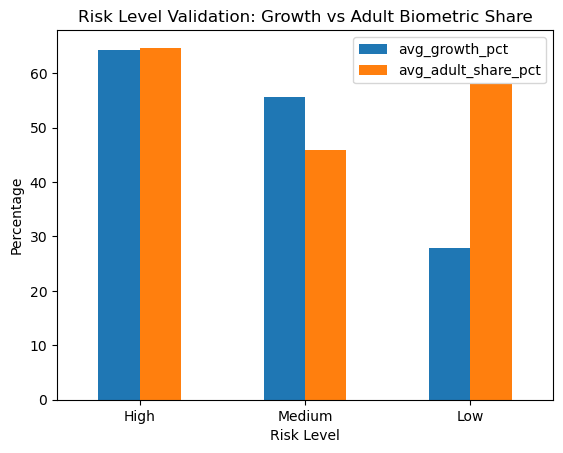

In [127]:
validation_table.set_index('risk_level')[[
    'avg_growth_pct',
    'avg_adult_share_pct'
]].plot(kind='bar')

plt.title('Risk Level Validation: Growth vs Adult Biometric Share')
plt.ylabel('Percentage')
plt.xlabel('Risk Level')
plt.xticks(rotation=0)
plt.show()
